In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


In [8]:
PROJECT_ROOT = Path.cwd()

print("Current working directory:")
print(PROJECT_ROOT)

Current working directory:
d:\VS Code\DataPilot\notebooks\phase_01


In [12]:
DATA_PATH = PROJECT_ROOT / "D:\\VS Code\\DataPilot\\data\\raw\\superstore.csv"
print(DATA_PATH)

D:\VS Code\DataPilot\data\raw\superstore.csv


In [13]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()

print("Current working directory:", PROJECT_ROOT)


Current working directory: d:\VS Code\DataPilot\notebooks\phase_01


In [14]:

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [16]:

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9800
Columns: 18


In [17]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [19]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [22]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [23]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)


Duplicate rows: 0


In [24]:
# Convert date columns

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True,
    errors="coerce"
)

df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [25]:
# Check invalid dates

print("Invalid Order Dates:", df["Order Date"].isnull().sum())
print("Invalid Ship Dates:", df["Ship Date"].isnull().sum())

Invalid Order Dates: 0
Invalid Ship Dates: 0


In [26]:
# Clean Postal Code

df["Postal Code"] = df["Postal Code"].astype("Int64")

df[["Postal Code"]].head()

,Postal Code
0,42420
1,42420
2,90036
3,33311
4,33311


In [29]:
#Create date features
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Order Quarter"] = df["Order Date"].dt.quarter
df["Order Day"] = df["Order Date"].dt.day


df[
    [
        "Order Date",
        "Order Year",
        "Order Month",
        "Order Month Name",
        "Order Quarter"
    ]
].head()

,Order Date,Order Year,Order Month,Order Month Name,Order Quarter
0,2017-11-08,2017,11,November,4
1,2017-11-08,2017,11,November,4
2,2017-06-12,2017,6,June,2
3,2016-10-11,2016,10,October,4
4,2016-10-11,2016,10,October,4


In [30]:
# Cell 21 — Calculate shipping duration

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[
    ["Order Date", "Ship Date", "Shipping Days"]
].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            9800 non-null   int64         
 1   Order ID          9800 non-null   str           
 2   Order Date        9800 non-null   datetime64[us]
 3   Ship Date         9800 non-null   datetime64[us]
 4   Ship Mode         9800 non-null   str           
 5   Customer ID       9800 non-null   str           
 6   Customer Name     9800 non-null   str           
 7   Segment           9800 non-null   str           
 8   Country           9800 non-null   str           
 9   City              9800 non-null   str           
 10  State             9800 non-null   str           
 11  Postal Code       9789 non-null   Int64         
 12  Region            9800 non-null   str           
 13  Product ID        9800 non-null   str           
 14  Category          9800 non-null   s

In [33]:
duplicate_rows

np.int64(0)

In [34]:
df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [38]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            9800 non-null   int64         
 1   Order ID          9800 non-null   str           
 2   Order Date        9800 non-null   datetime64[us]
 3   Ship Date         9800 non-null   datetime64[us]
 4   Ship Mode         9800 non-null   str           
 5   Customer ID       9800 non-null   str           
 6   Customer Name     9800 non-null   str           
 7   Segment           9800 non-null   str           
 8   Country           9800 non-null   str           
 9   City              9800 non-null   str           
 10  State             9800 non-null   str           
 11  Postal Code       9789 non-null   Int64         
 12  Region            9800 non-null   str           
 13  Product ID        9800 non-null   str           
 14  Category          9800 non-null   s

In [39]:
# Basic Sales KPIs

total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
median_sales = df["Sales"].median()

unique_orders = df["Order ID"].nunique()
unique_customers = df["Customer ID"].nunique()
unique_products = df["Product ID"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Average Sales per Row: ${average_sales:,.2f}")
print(f"Median Sales per Row: ${median_sales:,.2f}")
print(f"Unique Orders: {unique_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Unique Products: {unique_products:,}")

Total Sales: $2,261,536.78
Average Sales per Row: $230.77
Median Sales per Row: $54.49
Unique Orders: 4,922
Unique Customers: 793
Unique Products: 1,861


In [52]:
# Sales by Region

sales_by_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_region

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

In [54]:
# Cell 25 — Sales by Category

sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_category

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [55]:
# Sales by Sub-Category

sales_by_subcategory = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_subcategory

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

In [43]:
# Sales by Customer Segment

sales_by_segment = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_segment

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

In [56]:
# Top 10 States by Sales

top_states = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

In [57]:
#Top 10 Cities by Sales

top_cities = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cities

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64

In [58]:
# Top 10 Products by Sales

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [59]:
# Sales by Year

sales_by_year = (
    df.groupby("Order Year")["Sales"]
    .sum()
    .sort_index()
)

sales_by_year

Order Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

In [60]:
#  Monthly Sales Trend

monthly_sales = (
    df.groupby(
        [df["Order Date"].dt.to_period("M")]
    )["Sales"]
    .sum()
)

monthly_sales.head(12)

Order Date
2015-01    14205.7070
2015-02     4519.8920
2015-03    55205.7970
2015-04    27906.8550
2015-05    23644.3030
2015-06    34322.9356
2015-07    33781.5430
2015-08    27117.5365
2015-09    81623.5268
2015-10    31453.3930
2015-11    77907.6607
2015-12    68167.0585
Freq: M, Name: Sales, dtype: float64

In [61]:
#Convert monthly period to timestamp

monthly_sales_plot = monthly_sales.copy()
monthly_sales_plot.index = monthly_sales_plot.index.to_timestamp()

monthly_sales_plot.head()

Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

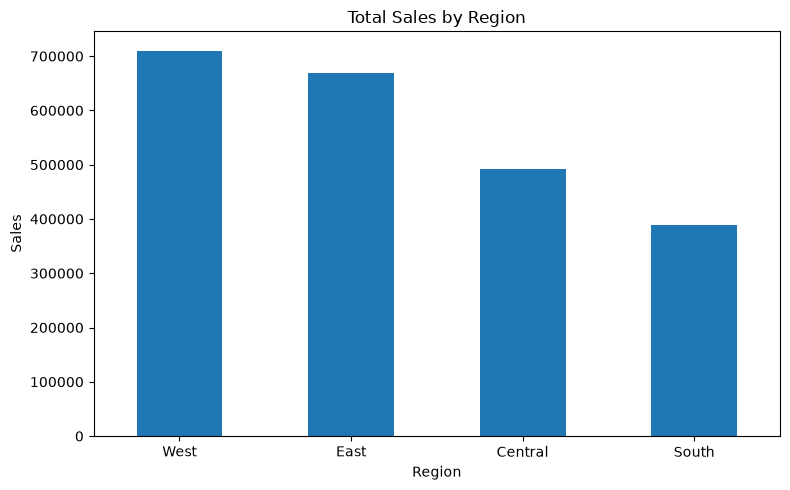

In [62]:
# Sales by Region Chart

plt.figure(figsize=(8, 5))

sales_by_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

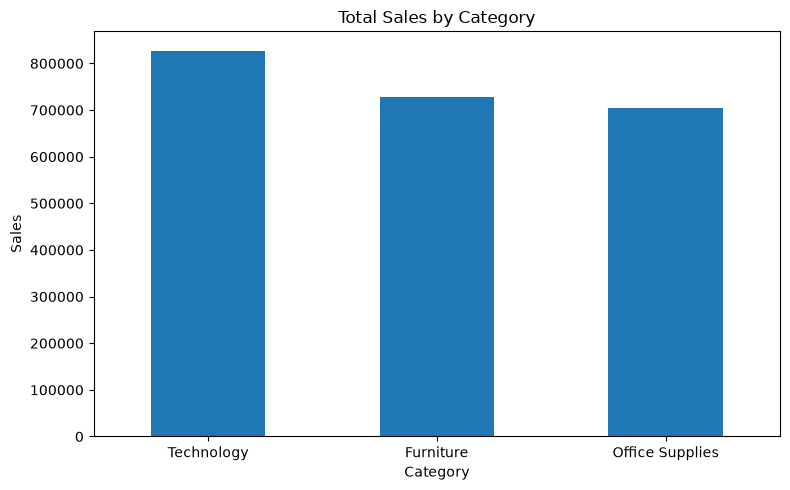

In [63]:
#  Sales by Category Chart

plt.figure(figsize=(8, 5))

sales_by_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

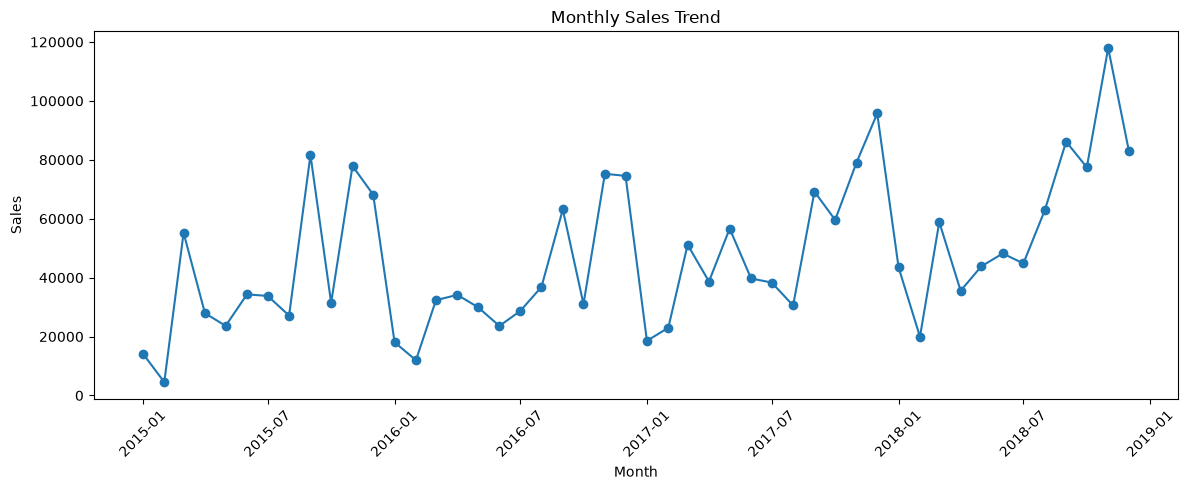

In [64]:
#  Monthly Sales Trend

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales_plot.index,
    monthly_sales_plot.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [65]:
#  Average Shipping Days

average_shipping_days = df["Shipping Days"].mean()

print(f"Average Shipping Time: {average_shipping_days:.2f} days")

Average Shipping Time: 3.96 days


In [66]:
# Shipping Performance by Mode

shipping_by_mode = (
    df.groupby("Ship Mode")["Shipping Days"]
    .mean()
    .sort_values()
)

shipping_by_mode

Ship Mode
Same Day          0.044610
First Class       2.179214
Second Class      3.249211
Standard Class    5.008363
Name: Shipping Days, dtype: float64

In [67]:
# Orders by Ship Mode

orders_by_ship_mode = df["Ship Mode"].value_counts()

orders_by_ship_mode

Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

In [69]:
# Check shipping duration range

print("Minimum Shipping Days:", df["Shipping Days"].min())
print("Maximum Shipping Days:", df["Shipping Days"].max())
print("Negative Shipping Days:", (df["Shipping Days"] < 0).sum())

Minimum Shipping Days: 0
Maximum Shipping Days: 7
Negative Shipping Days: 0


In [70]:
# Same Day shipping check

df[df["Ship Mode"] == "Same Day"]["Shipping Days"].value_counts().sort_index()

Shipping Days
0    514
1     24
Name: count, dtype: int64

In [71]:
# Year-over-Year Sales Growth

yearly_growth = sales_by_year.pct_change() * 100

yearly_growth

Order Year
2015          NaN
2016    -4.255484
2017    30.636812
2018    20.303396
Name: Sales, dtype: float64

In [72]:
# Yearly Sales Performance

yearly_performance = pd.DataFrame({
    "Sales": sales_by_year,
    "Growth %": yearly_growth
})

yearly_performance

,Sales,Growth %
Order Year,,
2015,479856.2081,NaN
2016,459436.0054,-4.255484
2017,600192.5500,30.636812
2018,722052.0192,20.303396


In [73]:
region_share = (
    sales_by_region / sales_by_region.sum() * 100
).round(2)

region_share

Region
West       31.40
East       29.60
Central    21.78
South      17.21
Name: Sales, dtype: float64

In [74]:
region_summary = pd.DataFrame({
    "Sales": sales_by_region,
    "Share %": region_share
})

region_summary

,Sales,Share %
Region,,
West,710219.6845,31.40
East,669518.7260,29.60
Central,492646.9132,21.78
South,389151.4590,17.21


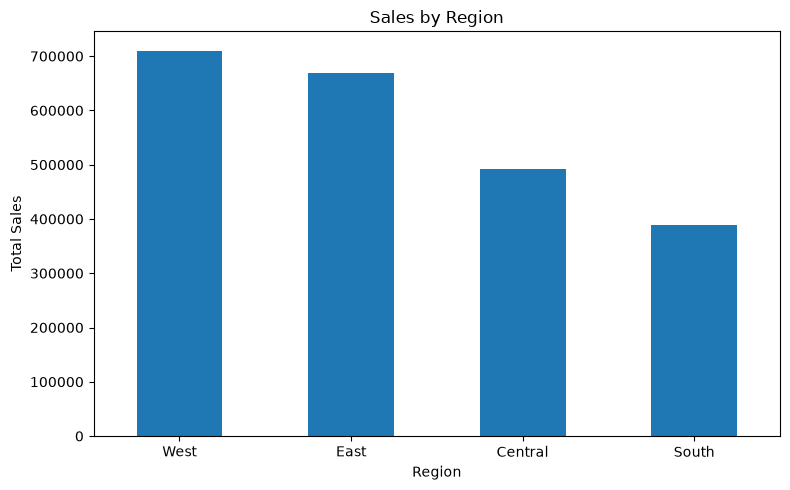

In [75]:
plt.figure(figsize=(8, 5))

sales_by_region.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [76]:
yearly_performance

,Sales,Growth %
Order Year,,
2015,479856.2081,NaN
2016,459436.0054,-4.255484
2017,600192.5500,30.636812
2018,722052.0192,20.303396


In [77]:
print("Minimum:", df["Shipping Days"].min())
print("Maximum:", df["Shipping Days"].max())
print("Negative:", (df["Shipping Days"] < 0).sum())


Minimum: 0
Maximum: 7
Negative: 0
